# Przygotowanie danych


In [258]:
#Załadowanie danych

import zipfile
import os

zip_name = "archive.zip" #Po załadowaniu folderu zip ze zbiorem danych do colab

with zipfile.ZipFile(zip_name, 'r') as zip_ref: #Rozpakowanie zip
    zip_ref.extractall("The_Berka_Dataset")

os.listdir("The_Berka_Dataset") #Folder zip został rozpakowany do folderu "The_Berka_Dataset"

['client.csv',
 'order.csv',
 'district.csv',
 'card.csv',
 'disp.csv',
 'loan.csv',
 'account.csv',
 'trans.csv']

In [259]:
import pandas as pd
import glob

path = "The_Berka_Dataset/*.csv"
files = glob.glob(path) #Glob pozyskuje ścieżkę

dfs = {} #Tworzę na razie pusty słownik dfs
for f in files: #Wypełniam słownik
    name = f.split("/")[-1].replace(".csv","")
    dfs[name] = pd.read_csv(f, sep=';', header=None if name=='district' else 0) #Kluczami są nazwy plików, a wartościami pliki w postaci ramek danych
    print(name, dfs[name].shape) #Sprawdzenie, czy w pliki w porządku się załadowały i czy ramki danych mają odpowiednią liczbę wierszy


client (5369, 3)
order (6471, 6)
district (78, 16)
card (892, 4)
disp (5369, 4)
loan (682, 7)
account (4500, 4)
trans (1056320, 10)


/tmp/ipython-input-1915733603.py:10: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[name] = pd.read_csv(f, sep=';', header=None if name=='district' else 0) #Kluczami są nazwy plików, a wartościami pliki w postaci ramek danych


In [260]:
dfs["district"] = pd.read_csv(
    "The_Berka_Dataset/district.csv",
    sep=";", #Separatorem w Berka Dataset jest średnik
    header=0 #W tabelce pliku district.csv jest nagłówek
)

dfs["district"].columns #Kolumny w district mają nazwy A1, A2,..., A16

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16'],
      dtype='object')

In [261]:
#Zmienię więc je na inne nazwy, które mówią mi co znajduje się w każdej kolumnie, aby lepiej się pracowało
dfs["district"].columns = [
    "district_id",
    "district_name",
    "region",
    "inhabitants",
    "municipalities_499",
    "municipalities_1999",
    "municipalities_9999",
    "municipalities_10000",
    "cities",
    "urban_ratio",
    "average_salary",
    "unemployment_rate_95",
    "unemployment_rate_96",
    "entrepreneurs_per_1000",
    "crimes_95",
    "crimes_96"
]

In [262]:
dfs["district"].head() #Teraz kolumny mają sensowne nazwy

,district_id,district_name,region,inhabitants,municipalities_499,municipalities_1999,municipalities_9999,municipalities_10000,cities,urban_ratio,average_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96
0,1,Hl.m. Praha,Prague,1204953,0,0,0,1,1,100.0,12541,0.29,0.43,167,85677,99107
1,2,Benesov,central Bohemia,88884,80,26,6,2,5,46.7,8507,1.67,1.85,132,2159,2674
2,3,Beroun,central Bohemia,75232,55,26,4,1,5,41.7,8980,1.95,2.21,111,2824,2813
3,4,Kladno,central Bohemia,149893,63,29,6,2,6,67.4,9753,4.64,5.05,109,5244,5892
4,5,Kolin,central Bohemia,95616,65,30,4,1,6,51.4,9307,3.85,4.43,118,2616,3040


In [263]:
#Wypisanie podstawowych informacji o każdej tabelce

for name, df in dfs.items():
    print(f"{name.upper()}")
    print(df.head())
    print(df.info())
    print(df.describe(include="all"))
    print("\n\n")

CLIENT
   client_id  birth_number  district_id
0          1        706213           18
1          2        450204            1
2          3        406009            1
3          4        561201            5
4          5        605703            5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   client_id     5369 non-null   int64
 1   birth_number  5369 non-null   int64
 2   district_id   5369 non-null   int64
dtypes: int64(3)
memory usage: 126.0 KB
None
          client_id   birth_number  district_id
count   5369.000000    5369.000000  5369.000000
mean    3359.011920  535114.970013    37.310114
std     2832.911984  172895.618429    25.043690
min        1.000000  110820.000000     1.000000
25%     1418.000000  406009.000000    14.000000
50%     2839.000000  540829.000000    38.000000
75%     4257.000000  681013.000000    60.000000
max    13998.

In [264]:
#Utworzenie w loan zmiennej opisywanej - default
#U nas pytanie brzmi: Czy pożyczka zostanie spłacona?
#statusy B, D -> 0
#pozostałe statusy -> 1

loan = dfs["loan"]
loan["default"] = loan["status"].isin(["B","D"]).astype(int)
loan.head() #Można zauważyć nową kolumnę z wartościami binarnymi

,loan_id,account_id,date,amount,duration,payments,status,default
0,5314,1787,930705,96396,12,8033.0,B,1
1,5316,1801,930711,165960,36,4610.0,A,0
2,6863,9188,930728,127080,60,2118.0,A,0
3,5325,1843,930803,105804,36,2939.0,A,0
4,7240,11013,930906,274740,60,4579.0,A,0


In [265]:
#Łączenie tabel - chcę pracować na jednej ramce danych, zaczynam więc łączenie ich po kolei

#1. loan i account na wartościach account_id
loan_acc = loan.merge(dfs["account"], on="account_id", how="left")
loan_acc.head()

,loan_id,account_id,date_x,amount,duration,payments,status,default,district_id,frequency,date_y
0,5314,1787,930705,96396,12,8033.0,B,1,30,POPLATEK TYDNE,930322
1,5316,1801,930711,165960,36,4610.0,A,0,46,POPLATEK MESICNE,930213
2,6863,9188,930728,127080,60,2118.0,A,0,45,POPLATEK MESICNE,930208
3,5325,1843,930803,105804,36,2939.0,A,0,12,POPLATEK MESICNE,930130
4,7240,11013,930906,274740,60,4579.0,A,0,1,POPLATEK TYDNE,930214


In [266]:
disp = dfs["disp"]
client = dfs["client"]

client.columns

Index(['client_id', 'birth_number', 'district_id'], dtype='object')

In [267]:
#2. disp i client na wartościach client_id
disp_client = disp.merge(client, on="client_id", how="left")
disp_client.head()

,disp_id,client_id,account_id,type,birth_number,district_id
0,1,1,1,OWNER,706213,18
1,2,2,2,OWNER,450204,1
2,3,3,2,DISPONENT,406009,1
3,4,4,3,OWNER,561201,5
4,5,5,3,DISPONENT,605703,5


In [268]:
#Ramka danych disp może mieć więcej niż jeden wiersz dla jednego account_id
#np. - dwa wiersze, jeżeli dla danego account_id mam OWNER i DISPONENT
#W analizie chcę przewidzieć czy dany account_id spłaci pożyczkę, nie interesuje mnie czy zrobi to OWNER czy DISPONENT
#Dlatego modyfikuję disp_client i tworzę nową oczyszczoną ramkę danych disp_clean, w której każdy account_id wystąpi dokładnie raz

if "type" in disp_client.columns: #Dla każdego account_id biorę tylko jeden wiersz - OWNER lub ewentualnie pierwszy wiersz
    owners = disp_client[disp_client["type"] == "OWNER"]
    if owners.empty:
        disp_clean = disp_client.groupby("account_id").first().reset_index()
    else:
        disp_clean = owners
else:
    disp_clean = disp_client.groupby("account_id").first().reset_index()

disp_clean.head()

,disp_id,client_id,account_id,type,birth_number,district_id
0,1,1,1,OWNER,706213,18
1,2,2,2,OWNER,450204,1
3,4,4,3,OWNER,561201,5
5,6,6,4,OWNER,190922,12
6,7,7,5,OWNER,290125,15


In [269]:
disp_clean["type"].unique() #Podsumowując usunęłam wszystkiech dysponentów i będe pracowała na tabelce uwzględniających tylko właścicieli kont

array(['OWNER'], dtype=object)

In [270]:
#3. loan, account, disp i client
loan_acc_client = loan_acc.merge(
    disp_clean[["account_id","client_id","district_id","birth_number"]],
    on="account_id",
    how="left"
)
loan_acc_client.head()

,loan_id,account_id,date_x,amount,duration,payments,status,default,district_id_x,frequency,date_y,client_id,district_id_y,birth_number
0,5314,1787,930705,96396,12,8033.0,B,1,30,POPLATEK TYDNE,930322,2166,30,475722
1,5316,1801,930711,165960,36,4610.0,A,0,46,POPLATEK MESICNE,930213,2181,46,680722
2,6863,9188,930728,127080,60,2118.0,A,0,45,POPLATEK MESICNE,930208,11314,45,360602
3,5325,1843,930803,105804,36,2939.0,A,0,12,POPLATEK MESICNE,930130,2235,14,405420
4,7240,11013,930906,274740,60,4579.0,A,0,1,POPLATEK TYDNE,930214,13539,63,780907


In [271]:
#Wystarczy nam jedna kolumna zawierająca district_id
loan_acc_client = loan_acc_client.rename(columns={"district_id_y": "district_id"})
loan_acc_client = loan_acc_client.drop(columns=["district_id_x"], errors="ignore")
loan_acc_client.head()

,loan_id,account_id,date_x,amount,duration,payments,status,default,frequency,date_y,client_id,district_id,birth_number
0,5314,1787,930705,96396,12,8033.0,B,1,POPLATEK TYDNE,930322,2166,30,475722
1,5316,1801,930711,165960,36,4610.0,A,0,POPLATEK MESICNE,930213,2181,46,680722
2,6863,9188,930728,127080,60,2118.0,A,0,POPLATEK MESICNE,930208,11314,45,360602
3,5325,1843,930803,105804,36,2939.0,A,0,POPLATEK MESICNE,930130,2235,14,405420
4,7240,11013,930906,274740,60,4579.0,A,0,POPLATEK TYDNE,930214,13539,63,780907


In [272]:
loan_acc_client["district_id"] = loan_acc_client["district_id"].astype(int) #Rzutowanie kolumny district_id na typ int w dwóch ramkach danych
dfs["district"]["district_id"] = dfs["district"]["district_id"].astype(int) #Przy łączeniu tabel typ musi się zgadzać

#4. loan, account, disp, client i district
loan_full = loan_acc_client.merge(
    dfs["district"],
    on="district_id",
    how="left"
)

loan_full.head()

,loan_id,account_id,date_x,amount,duration,payments,status,default,frequency,date_y,...,municipalities_9999,municipalities_10000,cities,urban_ratio,average_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96
0,5314,1787,930705,96396,12,8033.0,B,1,POPLATEK TYDNE,930322,...,8,2,10,81.8,9650,3.38,3.67,100,2985,2804
1,5316,1801,930711,165960,36,4610.0,A,0,POPLATEK MESICNE,930213,...,7,3,10,73.5,8369,1.79,2.31,117,2854,2618
2,6863,9188,930728,127080,60,2118.0,A,0,POPLATEK MESICNE,930208,...,6,1,5,53.5,8390,2.28,2.89,132,2080,2122
3,5325,1843,930803,105804,36,2939.0,A,0,POPLATEK MESICNE,930130,...,10,1,9,74.8,10045,1.42,1.71,135,6604,6295
4,7240,11013,930906,274740,60,4579.0,A,0,POPLATEK TYDNE,930214,...,5,1,5,50.5,8288,3.79,4.52,110,1562,1460


# Eksploracyjna analiza danych (EDA)

In [273]:
loan_full.describe(include='all').T #Podstawowe statystyki

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,682.0,NaN,NaN,NaN,6172.466276,682.579279,4959.0,5577.5,6176.5,6752.5,7308.0
account_id,682.0,NaN,NaN,NaN,5824.162757,3283.512681,2.0,2967.0,5738.5,8686.0,11362.0
date_x,682.0,NaN,NaN,NaN,963027.910557,14616.406049,930705.0,950704.5,970206.5,971212.5,981208.0
amount,682.0,NaN,NaN,NaN,151410.175953,113372.40631,4980.0,66732.0,116928.0,210654.0,590820.0
duration,682.0,NaN,NaN,NaN,36.492669,17.075219,12.0,24.0,36.0,48.0,60.0
payments,682.0,NaN,NaN,NaN,4190.664223,2215.830344,304.0,2477.0,3934.0,5813.5,9910.0
status,682,4,C,403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,682.0,NaN,NaN,NaN,0.111437,0.314903,0.0,0.0,0.0,0.0,1.0
frequency,682,3,POPLATEK MESICNE,559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_y,682.0,NaN,NaN,NaN,952313.549853,14155.440348,930113.0,940523.0,960126.0,961017.5,971222.0


In [274]:
loan_full.isna().sum().sort_values(ascending=False) #Ile wartości pustych jest w każdej klumnie

,0
loan_id,0
account_id,0
date_x,0
amount,0
duration,0
payments,0
status,0
default,0
frequency,0
date_y,0


In [275]:
loan_full.isna().sum().sum() #Suma wszystkich wartości NaN dla pewności

np.int64(0)

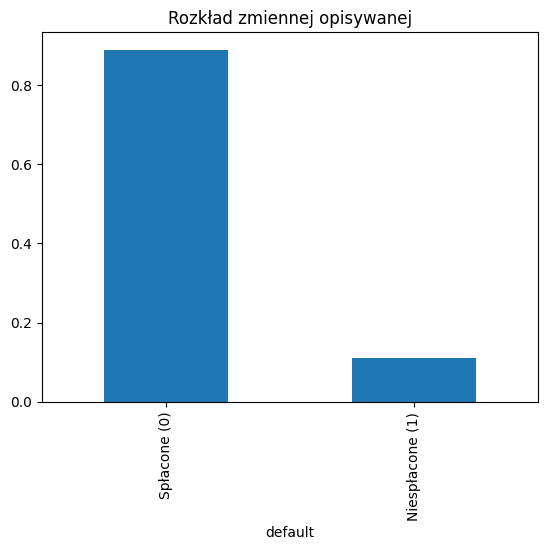

In [276]:
#Rozkład zmiennej opisywanej (default)

import seaborn as sns
import matplotlib.pyplot as plt

loan_full['default'].value_counts(normalize=True).plot(kind='bar')
plt.title("Rozkład zmiennej opisywanej")
plt.xticks([0,1], ['Spłacone (0)', 'Niespłacone (1)'])
plt.show()

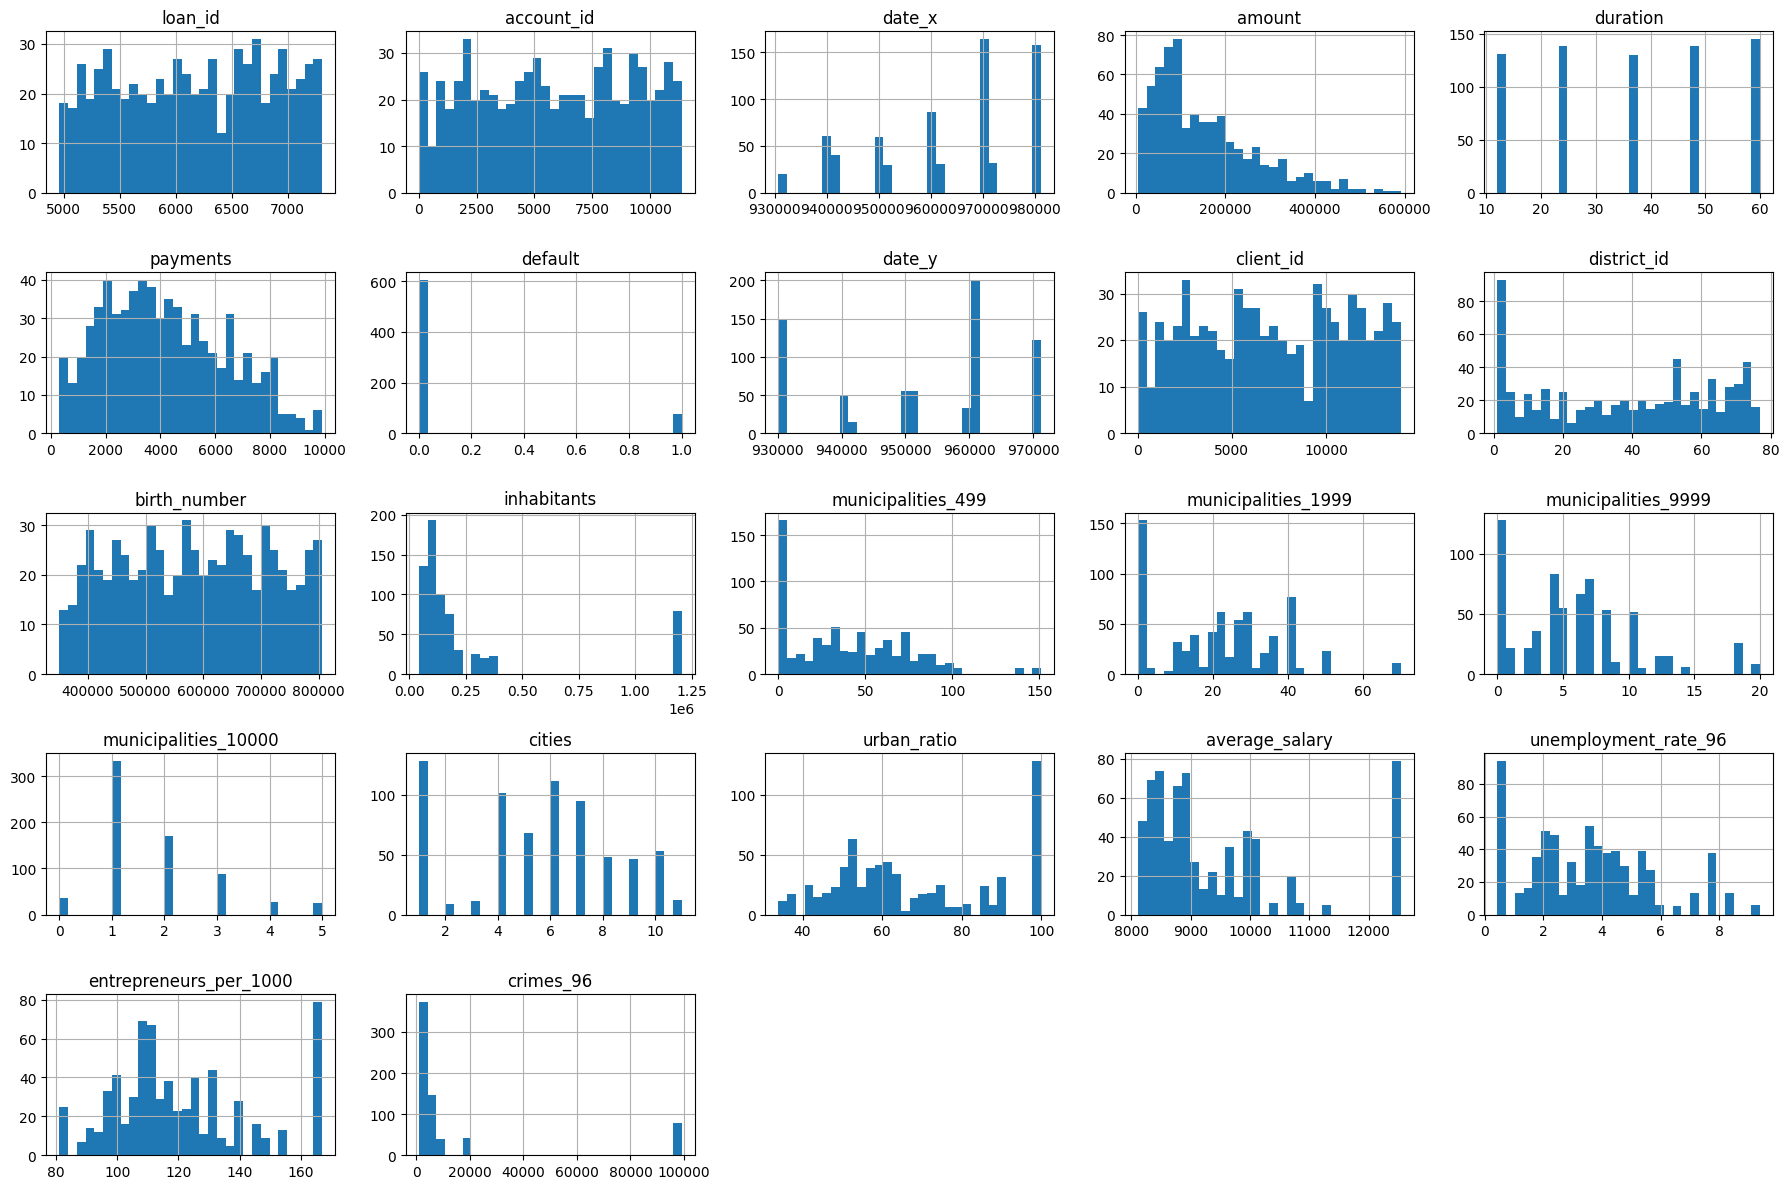

In [277]:
#Histogramy najważniejszych zmiennych numerycznych

num_cols = loan_full.select_dtypes(include=['int64','float64']).columns

loan_full[num_cols].hist(figsize=(18,12), bins=30)
plt.tight_layout()
plt.show()

In [278]:
#Chcę stworzyć kolumnę age - zrobię to wyliczając wiek na podstawie kolumny birth_number
#w Berka Dataset wiek jest zapisywany w następujący sposób:
#dla mężczyzn - data urodzenia: YY MM DD
#dla kobiet YY MM+50 D, więc jeżeli MM>50, to musi to być kobieta oraz jej miesiąc urodzenia to MM=MM-50
#Badany zbiór dotyczy banku działającego w latach 1993-1999, więc lata urodzenia klientów muszą mieć postać 19YY

def parse_birth_number_flexible(bn, ref_date=None):
    """
    bn: birth_number (int or str)
    ref_date: referencyjna data (loan_date) - pd.Timestamp
    """
    try:
        bn = str(int(bn))
        if len(bn) < 6:
            return pd.NaT
        yy = int(bn[:2])
        mm = int(bn[2:4])
        dd = int(bn[4:6])
    except:
        return pd.NaT

    # korekta dla kobiet
    if mm > 50:
        mm -= 50

    candidates = []
    for century in (1900, 2000):
        year = century + yy
        try:
            d = pd.Timestamp(year, mm, dd)
            candidates.append(d)
        except:
            pass

    if not candidates:
        return pd.NaT

    # jeśli nie ma ref_date, preferujemy 1900+
    if ref_date is None or pd.isna(ref_date):
        return candidates[0]

    # wybór pasujący do daty pożyczki
    valid = []
    for d in candidates:
        age = (ref_date - d).days // 365
        if (d <= ref_date) and (15 <= age <= 100):
            valid.append((d, age))

    if valid:
        return sorted(valid, key=lambda x: x[1])[0][0]

    # w ostateczności wybierz najbliższą, ale nie większą
    valid2 = [d for d in candidates if d <= ref_date]
    if valid2:
        return max(valid2)

    return candidates[0]

In [279]:
loan_full["loan_date"] = pd.to_datetime(
    loan_full["date_x"].astype(str),
    format="%y%m%d",
    errors="coerce"
)

In [280]:
loan_full['birth_date'] = loan_full.apply(
    lambda r: parse_birth_number_flexible(r['birth_number'], ref_date=r['loan_date']),
    axis=1
)

In [281]:
loan_full['age'] = (loan_full['loan_date'] - loan_full['birth_date']).dt.days // 365

In [282]:
loan_full[loan_full['age'] < 0][['birth_number','birth_date','loan_date','age']].head() #Nie ma ujemnego wieku, co jest dobrym znakiem

,birth_number,birth_date,loan_date,age


In [283]:
loan_full.head()

,loan_id,account_id,date_x,amount,duration,payments,status,default,frequency,date_y,...,urban_ratio,average_salary,unemployment_rate_95,unemployment_rate_96,entrepreneurs_per_1000,crimes_95,crimes_96,loan_date,birth_date,age
0,5314,1787,930705,96396,12,8033.0,B,1,POPLATEK TYDNE,930322,...,81.8,9650,3.38,3.67,100,2985,2804,1993-07-05,1947-07-22,45
1,5316,1801,930711,165960,36,4610.0,A,0,POPLATEK MESICNE,930213,...,73.5,8369,1.79,2.31,117,2854,2618,1993-07-11,1968-07-22,24
2,6863,9188,930728,127080,60,2118.0,A,0,POPLATEK MESICNE,930208,...,53.5,8390,2.28,2.89,132,2080,2122,1993-07-28,1936-06-02,57
3,5325,1843,930803,105804,36,2939.0,A,0,POPLATEK MESICNE,930130,...,74.8,10045,1.42,1.71,135,6604,6295,1993-08-03,1940-04-20,53
4,7240,11013,930906,274740,60,4579.0,A,0,POPLATEK TYDNE,930214,...,50.5,8288,3.79,4.52,110,1562,1460,1993-09-06,1978-09-07,15


In [285]:
loan_full = loan_full[loan_full["district_id"] != 69] #Region o district_id=69 ma '?' w jednej z kolumn numerycznych i przeszkadza w poźniejszych działaniach

In [286]:
#Korelacje zmiennych numerycznych - tabela
corr = loan_full.corr(numeric_only=True)['default'].sort_values(ascending=False)
corr

,default
default,1.000000
payments,0.181517
amount,0.162534
district_id,0.029114
unemployment_rate_96,0.028524
duration,0.020150
municipalities_499,0.002644
urban_ratio,0.000325
age,-0.000228
municipalities_1999,-0.002442


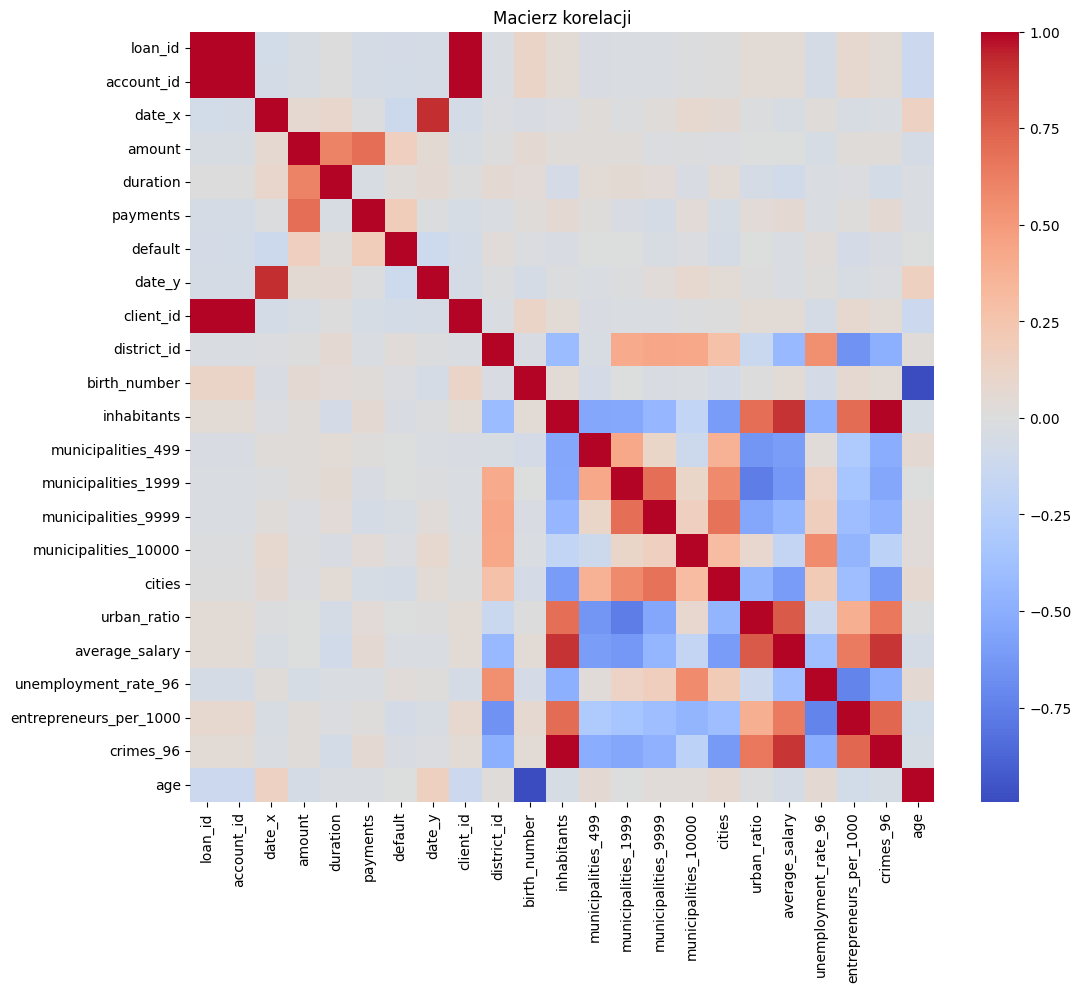

In [287]:
#Korelacje zmiennych numerycznych - macierz korelacji, heatmap
plt.figure(figsize=(12,10))
sns.heatmap(loan_full.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title("Macierz korelacji")
plt.show()

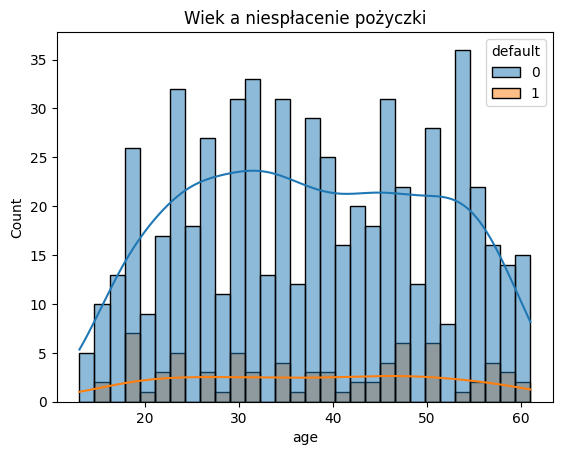

In [288]:
#Wpływ wieku na niespłacanie pożyczki
sns.histplot(data=loan_full, x='age', hue='default', bins=30, kde=True)
plt.title("Wiek a niespłacenie pożyczki")
plt.show()

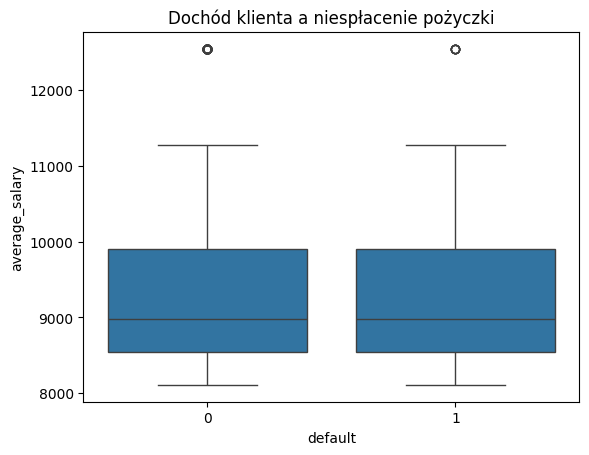

In [289]:
#Wpływ średniago dochodu na niespłacanie pożyczki
sns.boxplot(data=loan_full, x='default', y='average_salary')
plt.title("Dochód klienta a niespłacenie pożyczki")
plt.show()

In [290]:
trans = dfs["trans"]

In [291]:
trans_agg = trans.groupby("account_id").agg( #Agregacje transakcji dla każdego account_id
    trans_count=("amount", "count"), #liczba transakcji na konto
    trans_amount_sum=("amount", "sum"), #suma transakcji na konto
    trans_amount_mean=("amount", "mean") #średnia kwota transakcji
).reset_index()

In [292]:
loan_full["account_id"] = loan_full["account_id"].astype(int) #Porównanie typów danych
trans_agg["account_id"] = trans_agg["account_id"].astype(int)

loan_full = loan_full.merge(trans_agg, on="account_id", how="left") #Dołączenie danych do loan_full

#Uzupełnienie braków zerami - niektórzy mogą nie mieć transakcji
loan_full["trans_count"] = loan_full["trans_count"].fillna(0)
loan_full["trans_amount_sum"] = loan_full["trans_amount_sum"].fillna(0)
loan_full["trans_amount_mean"] = loan_full["trans_amount_mean"].fillna(0)

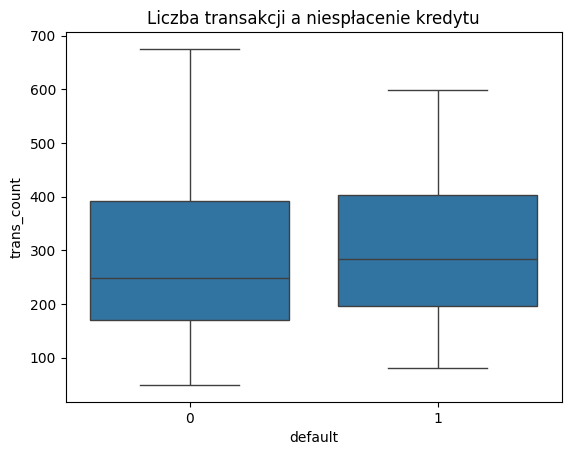

In [293]:
#Wpływ aktywności transakcyjnej na default
sns.boxplot(data=loan_full, x='default', y='trans_count')
plt.title("Liczba transakcji a niespłacenie kredytu")
plt.show()

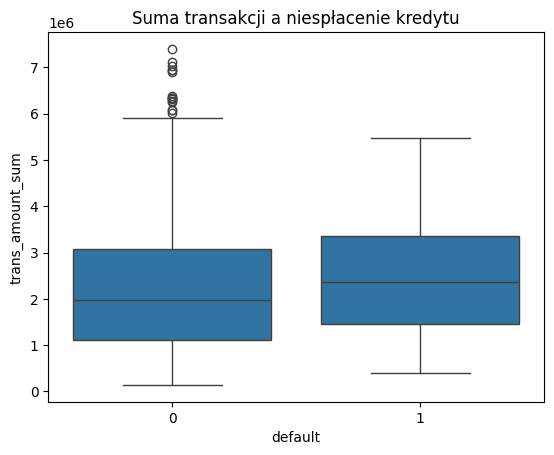

In [294]:
#Wpływ sum transakcji na default
sns.boxplot(data=loan_full, x='default', y='trans_amount_sum')
plt.title("Suma transakcji a niespłacenie kredytu")
plt.show()

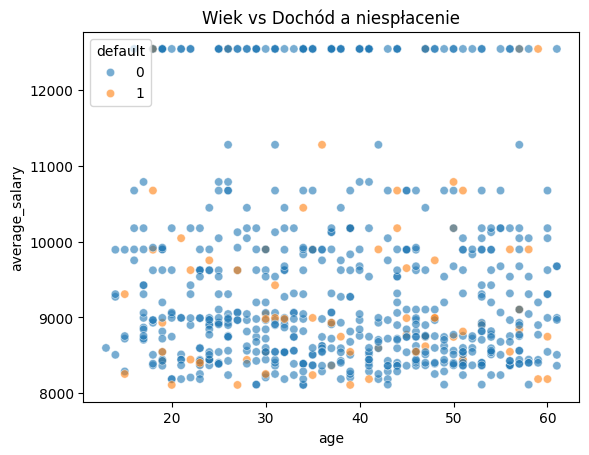

In [295]:
#Scatterploty - ależności między cechami klientów a niespłacaniem

#Wpływ wieku i średnich zarobków
sns.scatterplot(
    data=loan_full,
    x='age',
    y='average_salary',
    hue='default',
    alpha=0.6
)
plt.title("Wiek vs Dochód a niespłacenie")
plt.show()

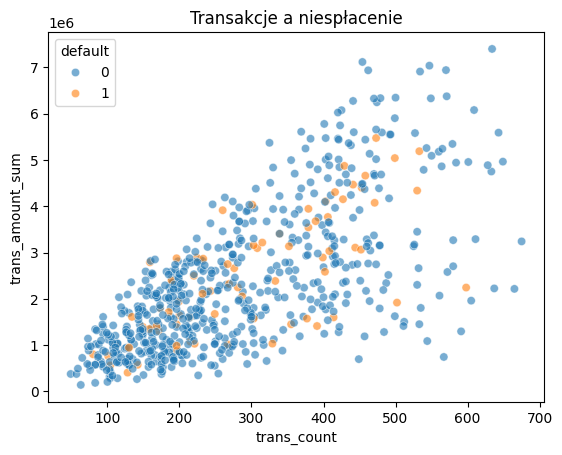

In [296]:
#Wpływ liczb i wartości transakcji
sns.scatterplot(
    data=loan_full,
    x='trans_count',
    y='trans_amount_sum',
    hue='default',
    alpha=0.6
)
plt.title("Transakcje a niespłacenie")
plt.show()

# Budowa modelu predykcyjnego

In [297]:
#Ładowanie bibliotek
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

In [298]:
try: #XGBoost
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

In [299]:
df = loan_full.copy() #Dane, na których pracujemy
target = 'default' #Zmienna opisywana

In [300]:
y = df[target].astype(int)
X = df.drop(columns=[target])

In [301]:
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
high_card = [c for c in cat_cols if X[c].nunique() > 200]
if high_card:
    print("Usuwam kolumny kategoryczne o wysokiej kardynalności:", high_card)
    X = X.drop(columns=high_card)
    cat_cols = [c for c in cat_cols if c not in high_card]

In [302]:
um_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Liczba cech numerycznych: {len(num_cols)}, kategorycznych: {len(cat_cols)}")

Liczba cech numerycznych: 22, kategorycznych: 6


In [303]:
num_cols = [ #Cechy numeryczne
    'amount', 'duration', 'payments', 'inhabitants',
    'municipalities_499', 'municipalities_1999',
    'municipalities_9999', 'municipalities_10000',
    'cities', 'urban_ratio', 'average_salary',
    'unemployment_rate_95', 'unemployment_rate_96',
    'entrepreneurs_per_1000', 'crimes_95', 'crimes_96',
    'age', 'trans_count', 'trans_amount_sum', 'trans_amount_mean'
]

In [304]:
cat_cols = ['frequency', 'district_name', 'region'] #Cechy kategoryczne

In [305]:
#Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train/test sizes:", X_train.shape, X_test.shape, "Target ratio (train):", y_train.mean())

Train/test sizes: (505, 33) (169, 33) Target ratio (train): 0.10891089108910891


In [306]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

def build_pipeline(clf):
    return Pipeline(steps=[('pre', preprocessor), ('clf', clf)])

In [307]:
#Modele, które będę porównywać
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=42),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
}
if xgb_available:
    models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [308]:
#Trenowanie i ocena modeli

results = {}

for name, estimator in models.items():
    print("\n--- Trenowanie:", name)
    pipe = build_pipeline(estimator)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_proba) if y_proba is not None and len(np.unique(y_test))==2 else np.nan

    print(f"{name} — accuracy: {acc:.4f}, precision: {prec:.4f}, recall: {rec:.4f}, f1: {f1:.4f}, roc_auc: {roc:.4f}")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    results[name] = {
        'pipeline': pipe,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'metrics': {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'roc_auc':roc}
    }


--- Trenowanie: LogisticRegression
LogisticRegression — accuracy: 0.6331, precision: 0.1356, recall: 0.4211, f1: 0.2051, roc_auc: 0.5593
Confusion matrix:
[[99 51]
 [11  8]]
Classification report:
              precision    recall  f1-score   support

           0       0.90      0.66      0.76       150
           1       0.14      0.42      0.21        19

    accuracy                           0.63       169
   macro avg       0.52      0.54      0.48       169
weighted avg       0.81      0.63      0.70       169


--- Trenowanie: DecisionTree
DecisionTree — accuracy: 0.8698, precision: 0.3636, recall: 0.2105, f1: 0.2667, roc_auc: 0.5819
Confusion matrix:
[[143   7]
 [ 15   4]]
Classification report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       150
           1       0.36      0.21      0.27        19

    accuracy                           0.87       169
   macro avg       0.63      0.58      0.60       169
weighted avg 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [22:06:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [309]:
#Porównanie metryk modeli
res_df = pd.DataFrame({k: v['metrics'] for k,v in results.items()}).T
display(res_df.sort_values('recall', ascending=False))

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.633136,0.135593,0.421053,0.205128,0.559298
DecisionTree,0.869822,0.363636,0.210526,0.266667,0.581930
XGBoost,0.863905,0.250000,0.105263,0.148148,0.652982
RandomForest,0.875740,0.250000,0.052632,0.086957,0.620702


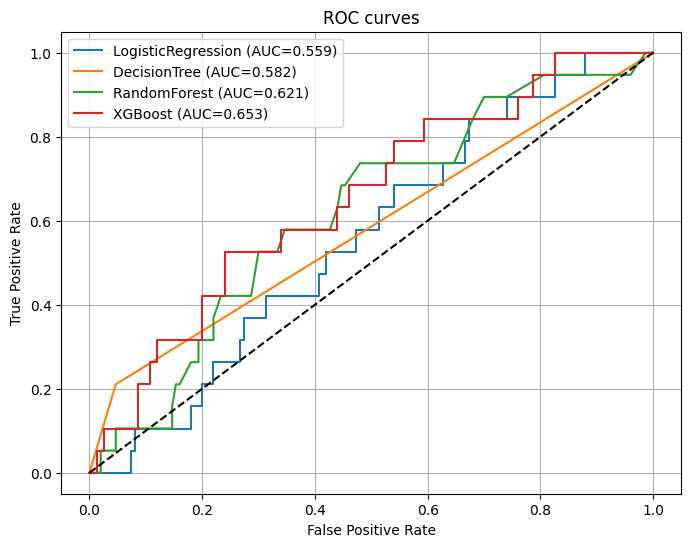

In [310]:
#Porównanie jakości modeli klasyfikacji poprzez narysowanie dla każdego z nich krzywej ROC oraz wyliczenie AUC (Area Under Curve)

plt.figure(figsize=(8,6))
for name, info in results.items():
    if info['y_proba'] is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, info['y_proba'])
    auc = roc_auc_score(y_test, info['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.grid()
plt.show()

Model with best recall: LogisticRegression


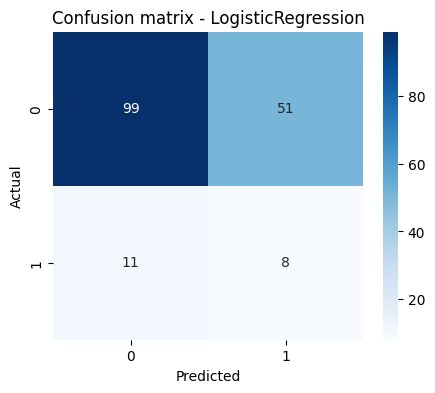

In [311]:
#Wybór najlepszego modelu pod względem recall i jego macierz pomyłek

best_model_name = res_df['recall'].sort_values(ascending=False).index[0]
print("Model with best recall:", best_model_name)
best_info = results[best_model_name]
cm = confusion_matrix(y_test, best_info['y_pred'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion matrix - {best_model_name}")
plt.show()

In [312]:
def get_feature_names(column_transformer): #Ta funkcja odzyskuje rzeczywiste nazwy kolumn po transformacjach
    # numeric names
    num_feats = []
    cat_feats = []
    # numeric
    for name, trans, cols in column_transformer.transformers_:
        if name == 'num':
            num_feats = cols
        elif name == 'cat':
            # get onehot feature names
            ohe = trans.named_steps['onehot']
            cat_names = ohe.get_feature_names_out(cols)
            cat_feats = list(cat_names)
    return list(num_feats) + cat_feats


Top features - RandomForest:


,0
payments,0.112210
amount,0.097684
trans_amount_mean,0.082939
trans_amount_sum,0.074829
trans_count,0.072879
age,0.062103
duration,0.037293
cities,0.031400
urban_ratio,0.031022
unemployment_rate_96,0.030341


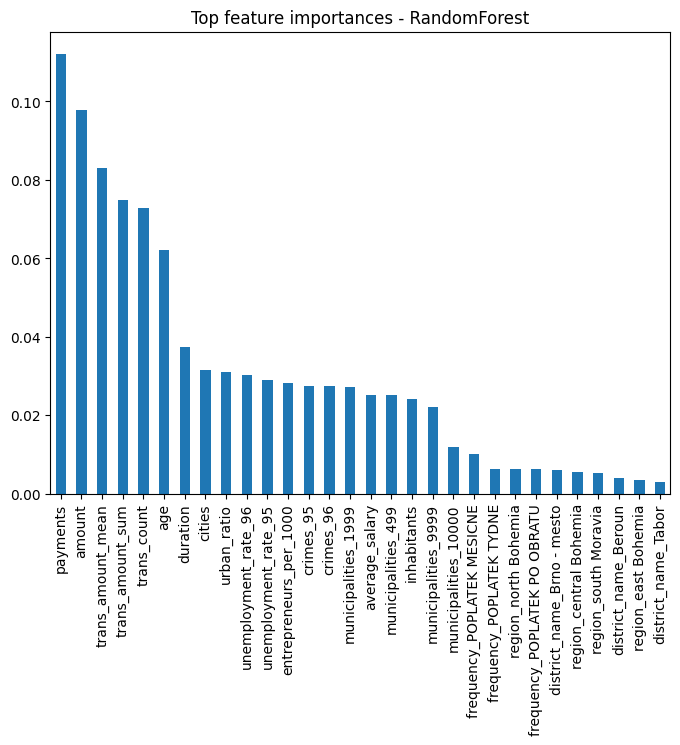


Top features - XGBoost:


,0
district_name_Brno - mesto,0.168762
frequency_POPLATEK PO OBRATU,0.126006
payments,0.059459
trans_amount_mean,0.047627
unemployment_rate_96,0.045945
frequency_POPLATEK MESICNE,0.042843
cities,0.036779
entrepreneurs_per_1000,0.035701
amount,0.034369
urban_ratio,0.033945


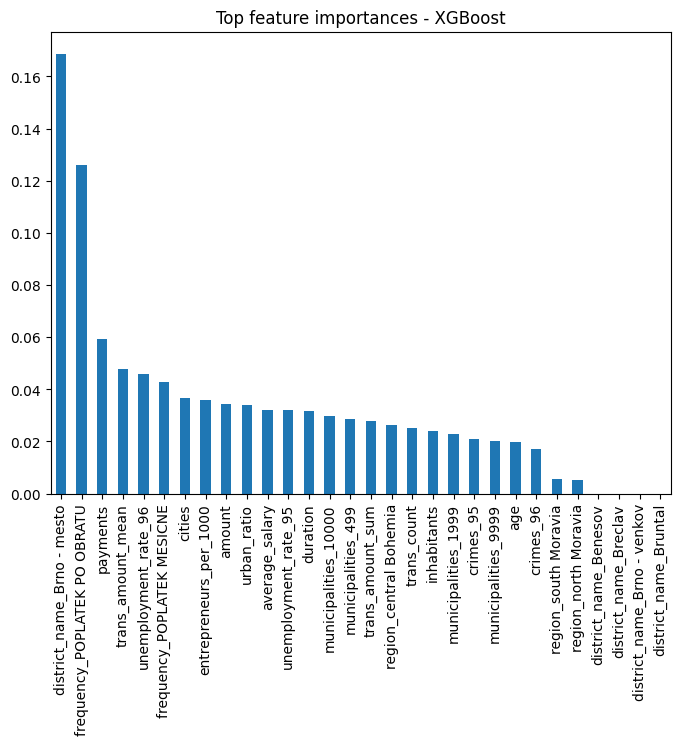

In [313]:
#Ranking ważności cech

for model_name in ['RandomForest','XGBoost']:
    if model_name in results:
        pipe = results[model_name]['pipeline']
        clf = pipe.named_steps['clf']
        try:
            feat_names = get_feature_names(pipe.named_steps['pre'])
            importances = clf.feature_importances_
            fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(30)
            print(f"\nTop features - {model_name}:")
            display(fi)
            # wykres
            plt.figure(figsize=(8,6))
            fi.plot(kind='bar')
            plt.title(f"Top feature importances - {model_name}")
            plt.show()
        except Exception as e:
            print(f"Nie udało się wyciągnąć importances dla {model_name}: {e}")

# Analiza wyników i wnioski

**Które cechy są najważniejsze dla przewidywania niespłacenia pożyczki?**

Najważniejsze cechy decydujące o niespłaceniu pożyczki:


*   Kwota pożyczki - Wyższe kwoty podwyższają ryzyko niespłacenia pożyczki; Klienci biorący bardzo duże pożyczki częściej trafiają do kategorii "niespłacone"
*  Średni dochód regionalny - Klienci z regionów o niższych średnich zarobkach częściej mają trudności ze spłatą pożyczki
*   Aktywność transakcyjna - Im mniejsza aktywność tym większe ryzyko niespłaty
*   Wiek - Młodsi klienci wykazują nieco więsze ryzyko niespłacenia pożyczki
*   Status regionu - Pożyczki w regionach o wysokim bezrobociu i przestępczości mają wyższe ryzyko niespłacalności


**Jakie czynniki najczęściej wpływają na to, że klient nie spłaca kredytu?**

Czynniki wpływające na niespłacenie pożyczki:
*   Status ekonomiczny regionu - stosunkowo niskie średnie zarobki, wysoki poziom bezrobocia i przestępczości
*   Niska aktywność transakcyjna na koncie
*   Wysokie kwoty pożyczek
*   Wiek - młodsi klienci częściej niespłacają





**Czy model można ulepszyć poprzez inżynierię cech lub dostrojenie hiperparametrów?**

Możliwości ulepszenia modelu:
*   Inżynieria cech - dodanie cech opisujących np.: stosunek zarobków do pożyczki, aktywność miesięczną transakcji klienta, wiek skategoryzowany (young, mid, senior)
*   Dostrojenie hiperparametrów - przeprowadzenie eksperymentów (przepuszczanie przez model różych zestawów hiperparametrów)






**Jak można wykorzystać ten model w praktyce, np. w bankowości?**

Model może być wykorzystywany w:
*   Ocenie zdolności kredytowej
*   Wczesnym ostrzeganiu o ryzyku - monitorowanie klientów i flagowanie zachowań, które podwyższają ryzyko niespłaty pożyczki
*   Personalizacji ofert - np. klient ryzykowny otrzyma mniejszą kwotę pożyczki/wyższe zabezpieczenie



